In [94]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

In [95]:
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.style.use("seaborn-v0_8-whitegrid")

In [96]:
RAW_DATA = Path("../data/raw")
PROCESSED_DATA = Path("../data/processed")
RESULTS = Path("../results/figures")

RAW_DATA.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

In [97]:
fields = [
    "NCTId",
    "BriefTitle",
    "Condition",
    "InterventionName",
    "Phase",
    "OverallStatus",
    "StartDate",
    "CompletionDate",
    "EnrollmentCount",
    "LocationCountry",
    "LeadSponsorName"
]

In [98]:
base_url = "https://clinicaltrials.gov/api/v2/studies"

params = {
    "expr": "cancer",   # oncology related trials
    "fields": ",".join(fields),
    "min_rnk": 1,
    "max_rnk": 5000,    # pulls 5000 trials
    "fmt": "json"
}

In [150]:
response = requests.get(base_url, params=params)
response.raise_for_status()

data = response.json()

raw_file = RAW_DATA / "oncology_trials_raw.json"
with open(raw_file, "w") as f:
    json.dump(data, f, indent=4)

print(f"Saved {len(data.get('studies', []))} trials to {raw_file}")

Saved 1000 trials to ../data/raw/oncology_trials_raw.json


In [99]:
all_trials = []
page_token = None

for i in range(5): # 5 pages x 1000 = 5000 trials

    params = {
        "query.term": "cancer",
        "pageSize": 1000,
        "format": "json"
    }

    if page_token:
        params["pageToken"] = page_token

    response = requests.get(base_url, params=params)
    response.raise_for_status()

    data = response.json()

    studies = data.get("studies", [])
    all_trials.extend(studies)

    page_token = data.get("nextPageToken")

    print("Collected trials:", len(all_trials))

print("Final dataset size:", len(all_trials))

Collected trials: 1000
Collected trials: 2000
Collected trials: 3000
Collected trials: 4000
Collected trials: 5000
Final dataset size: 5000


In [100]:
df = pd.json_normalize(all_trials)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 5000
Columns: 147


,hasResults,protocolSection.identificationModule.nctId,protocolSection.identificationModule.orgStudyIdInfo.id,protocolSection.identificationModule.secondaryIdInfos,protocolSection.identificationModule.organization.fullName,protocolSection.identificationModule.organization.class,protocolSection.identificationModule.briefTitle,protocolSection.identificationModule.officialTitle,protocolSection.statusModule.statusVerifiedDate,protocolSection.statusModule.overallStatus,...,resultsSection.moreInfoModule.pointOfContact.phoneExt,protocolSection.designModule.nPtrsToThisExpAccNctId,protocolSection.identificationModule.orgStudyIdInfo.type,protocolSection.identificationModule.orgStudyIdInfo.link,protocolSection.statusModule.expandedAccessInfo.nctId,protocolSection.statusModule.expandedAccessInfo.statusForNctId,protocolSection.designModule.expandedAccessTypes.individual,protocolSection.designModule.expandedAccessTypes.intermediate,documentSection.largeDocumentModule.noSap,protocolSection.designModule.expandedAccessTypes.treatment
0,False,NCT01296243,TOP205,"[{'id': 'PCCTC LOI # c10-071', 'type': 'OTHER'...",Genta Incorporated,INDUSTRY,Tesetaxel in Chemotherapy-naive Patients With ...,A Phase II Study of Single-agent Tesetaxel in ...,2012-07,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,False,NCT05228743,E20201130,NaN,Tianjin Medical University Cancer Institute an...,OTHER,Conversion Therapy of Hyperthermic Intraperito...,"A Randomized, Multicenter, Controlled Study to...",2021-09,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,False,NCT05829343,ROLADI - 1.0,NaN,S.M. Misericordia Hospital,OTHER,RObotic Versus LAparoscopic Colectomy for DIve...,RObotic Vs LAparoscopic Colectomy for DIvertic...,2025-01,RECRUITING,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,False,NCT04814108,ZN-c3-004,NaN,"K-Group, Beta, Inc., a wholly owned subsidiary...",INDUSTRY,A Study of ZN-c3 in Women With Recurrent or Pe...,"A Phase 2 Open-Label, Multicenter Study to Eva...",2024-11,RECRUITING,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,False,NCT05622825,202112056DIPC,NaN,National Taiwan University Hospital,OTHER,Valuation of the Safety and Efficacy of Combin...,Evaluation of the Safety and Efficacy of Combi...,2022-10,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
df.columns.tolist()

['hasResults',
 'protocolSection.identificationModule.nctId',
 'protocolSection.identificationModule.orgStudyIdInfo.id',
 'protocolSection.identificationModule.secondaryIdInfos',
 'protocolSection.identificationModule.organization.fullName',
 'protocolSection.identificationModule.organization.class',
 'protocolSection.identificationModule.briefTitle',
 'protocolSection.identificationModule.officialTitle',
 'protocolSection.statusModule.statusVerifiedDate',
 'protocolSection.statusModule.overallStatus',
 'protocolSection.statusModule.lastKnownStatus',
 'protocolSection.statusModule.expandedAccessInfo.hasExpandedAccess',
 'protocolSection.statusModule.startDateStruct.date',
 'protocolSection.statusModule.primaryCompletionDateStruct.date',
 'protocolSection.statusModule.primaryCompletionDateStruct.type',
 'protocolSection.statusModule.completionDateStruct.date',
 'protocolSection.statusModule.completionDateStruct.type',
 'protocolSection.statusModule.studyFirstSubmitDate',
 'protocolSecti

In [102]:
df.isna().mean().sort_values(ascending=False)

protocolSection.designModule.expandedAccessTypes.intermediate     0.9996
protocolSection.designModule.expandedAccessTypes.treatment        0.9990
documentSection.largeDocumentModule.noSap                         0.9990
protocolSection.designModule.nPtrsToThisExpAccNctId               0.9990
resultsSection.baselineCharacteristicsModule.typeUnitsAnalyzed    0.9990
                                                                   ...  
protocolSection.designModule.studyType                            0.0000
protocolSection.conditionsModule.conditions                       0.0000
protocolSection.sponsorCollaboratorsModule.leadSponsor.name       0.0000
protocolSection.descriptionModule.briefSummary                    0.0000
hasResults                                                        0.0000
Length: 147, dtype: float64

In [103]:
df_clean = df[[
    "protocolSection.identificationModule.nctId",
    "protocolSection.identificationModule.briefTitle",
    "protocolSection.conditionsModule.conditions",
    "protocolSection.designModule.phases",
    "protocolSection.statusModule.overallStatus",
    "protocolSection.designModule.enrollmentInfo.count",
    "protocolSection.contactsLocationsModule.locations",
    "protocolSection.sponsorCollaboratorsModule.leadSponsor.name",
    "protocolSection.statusModule.startDateStruct.date"
]].copy()

In [104]:
df_clean.columns = [
    "nct_id",
    "title",
    "condition",
    "phase",
    "status",
    "enrollment",
    "locations",
    "sponsor",
    "start_date"
]

In [105]:
# Flatten lists
df_clean["conditions"] = df_clean["condition"].apply(lambda x: x[0] if isinstance(x, list) else None)
df_clean["phase"] = df_clean["phase"].apply(lambda x: x[0] if isinstance(x, list) else None)

# Extract country
def extract_country(locations):
    if isinstance(locations, list) and len(locations) > 0:
        return locations[0].get("country")
    return None

df_clean["country"] = df_clean["locations"].apply(extract_country)

# Convert types
df_clean["enrollment"] = pd.to_numeric(df_clean["enrollment"], errors="coerce")
df_clean["start_date"] = pd.to_datetime(df_clean["start_date"], errors="coerce")

In [106]:
df_filtered = df_clean[df_clean["phase"].notna()].copy()

In [107]:
df_filtered.to_csv(PROCESSED_DATA / "onocology_trials_clean.csv", index=False)

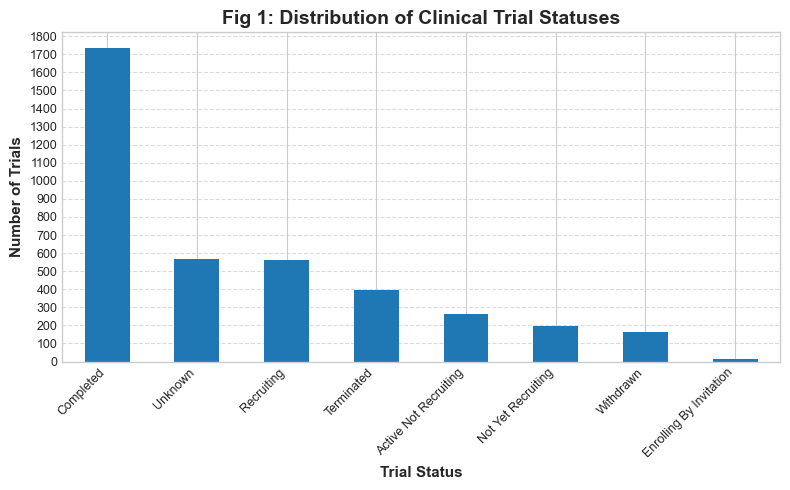

In [141]:
status_counts = (
    df_filtered["status"]
    .fillna("UNKNOWN")
    .str.replace("_", " ")
    .str.title()
    .value_counts()
    .head(8)
)

status_counts.plot(kind="bar")

plt.title("Fig 1: Distribution of Clinical Trial Statuses")
plt.xlabel("Trial Status")
plt.ylabel("Number of Trials")
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(100))
plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(50))
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(RESULTS / "status_distribution.png")
plt.show()

In [115]:
df_filtered["phase"].value_counts().head(10)

phase
PHASE2          1232
NA              1157
PHASE1           980
PHASE3           368
PHASE4           105
EARLY_PHASE1      72
Name: count, dtype: int64

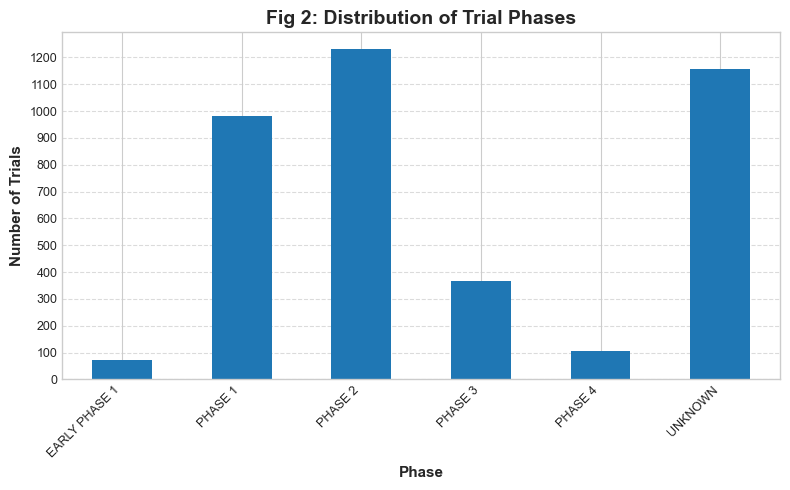

In [140]:
phase_clean = (
    df_filtered["phase"]
    .replace("NA", pd.NA)
    .fillna("UNKNOWN")
    .astype(str)
    .str.upper()
    .str.replace("_", " ", regex=False)
    .str.strip()
)

phase_clean = phase_clean.replace({
    "": "UNKNOWN",
    "PHASE1": "PHASE 1",
    "PHASE2": "PHASE 2",
    "PHASE3": "PHASE 3",
    "PHASE4": "PHASE 4",
    "EARLY PHASE1": "EARLY PHASE 1",
})

phase_clean = phase_clean[~phase_clean.str.contains("/", na=False)]

phase_order = [
    "EARLY PHASE 1",
    "PHASE 1",
    "PHASE 2",
    "PHASE 3",
    "PHASE 4",
    "UNKNOWN"
]

phase_counts = phase_clean.value_counts()
phase_counts = phase_counts.reindex(phase_order, fill_value=0)

phase_counts.plot(kind="bar")
plt.title("Fig 2: Distribution of Trial Phases")
plt.xlabel("Phase")
plt.ylabel("Number of Trials")
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(100))
plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(50))
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(RESULTS / "status_distribution.png")
plt.show()

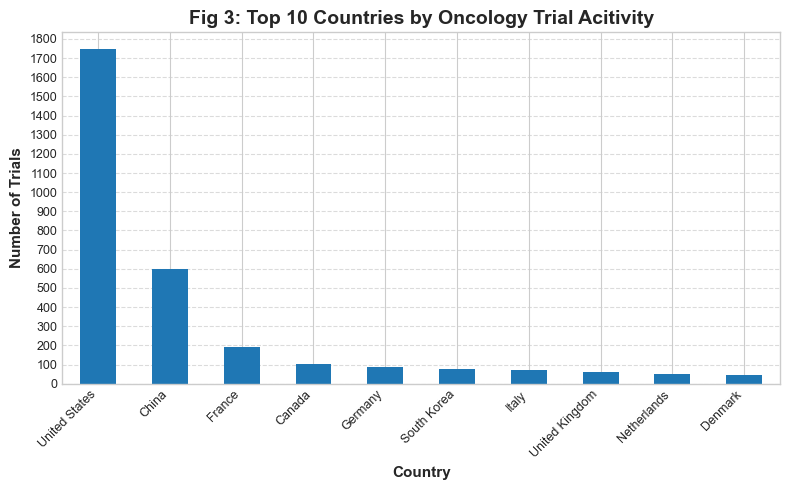

In [129]:
country_clean = (
    df_filtered["country"]
    .replace(["NA", "N/A", "NULL", ""], pd.NA)
    .dropna()
    .str.strip()
    .str.title()
)

country_counts = country_clean.value_counts().head(10)

country_counts.plot(kind="bar")

plt.title("Fig 3: Top 10 Countries by Oncology Trial Acitivity")
plt.xlabel("Country")
plt.ylabel("Number of Trials")
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(100))
plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(50))
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)  
plt.tight_layout()
plt.savefig(RESULTS / "country_distribution.png")
plt.show()

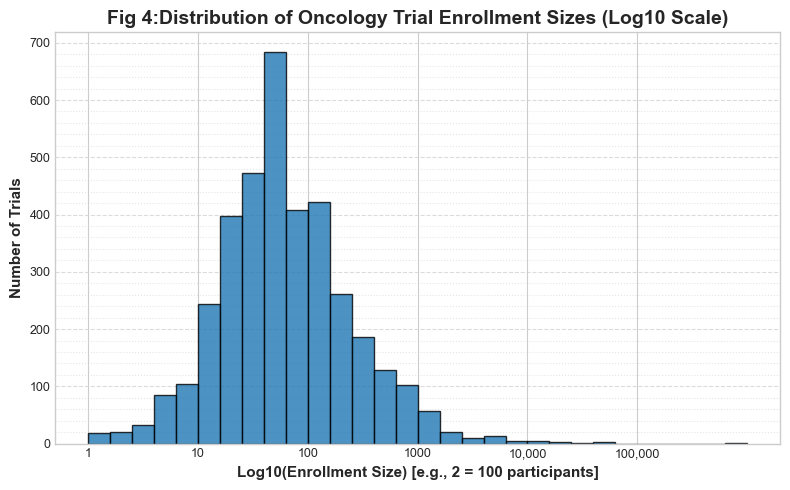

In [149]:
enrollment = df_filtered["enrollment"].dropna()
enrollment = enrollment[enrollment > 0]

fig, ax = plt.subplots(figsize=(8,5))

ax.hist(np.log10(enrollment), bins=30, color="#1f77b4", edgecolor="black", alpha=0.8)

plt.title("Fig 4:Distribution of Oncology Trial Enrollment Sizes (Log10 Scale)")
plt.xlabel("Log10(Enrollment Size) [e.g., 2 = 100 participants]")

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
ax.minorticks_on()

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(["1","10","100","1000","10,000","100,000"])

plt.ylabel("Number of Trials")

ax.grid(which="major", axis="y", linestyle="--", alpha=0.7)
ax.grid(which="minor", axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(RESULTS / "enrollment_distribution.png", dpi=300)
plt.show()

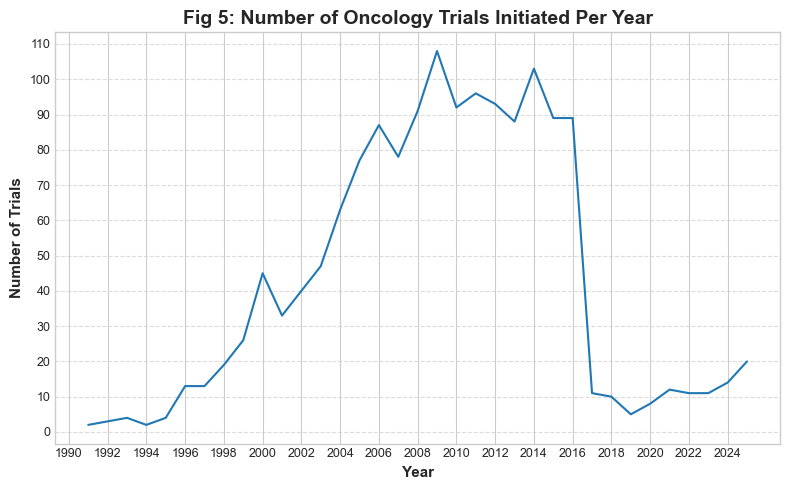

In [138]:
df_filtered["year"] = df_filtered["start_date"].dt.year

year_counts = year_counts[year_counts.index >= 1990]
year_counts = year_counts[year_counts.index <= 2025]

year_counts.plot()

plt.title("Fig 5: Number of Oncology Trials Initiated Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().yaxis.set_minor_locator(ticker.MultipleLocator(5))
plt.xticks(range(1990, 2026, 2))
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(RESULTS / "trials_per_year.png")
plt.show()

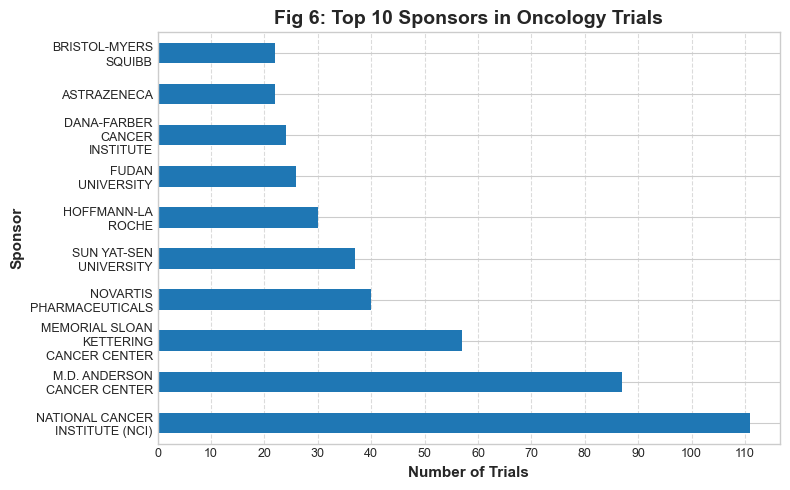

In [114]:
sponsor_counts = (
    df_filtered["sponsor"]
        .str.strip()
        .str.upper()
        .value_counts()
        .head(10)
)

sponsor_counts.plot(kind="barh")

import textwrap
def wrap_labels(labels, width=15):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

ax = sponsor_counts.plot(kind="barh")

ax.set_yticklabels(wrap_labels(sponsor_counts.index))

plt.title("Fig 6: Top 10 Sponsors in Oncology Trials", loc="center")
plt.xlabel("Number of Trials")
plt.ylabel("Sponsor")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(RESULTS / "top_sponsors.png")
plt.show()